# Task 3 — A/B Hypothesis Testing
**AlphaCare Insurance Solutions (ACIS) | KAIM9 Week 3**

**Objective:** Statistically validate or reject four null hypotheses about risk drivers in the ACIS portfolio. Results form the evidence base for a new segmentation and pricing strategy.

---

### KPI Definitions
| KPI | Formula |
|-----|---------|
| **Claim Frequency** | `Claimed == True` (proportion of policies with ≥1 claim) |
| **Claim Severity** | mean `ClaimAmount` where `Claimed == True` |
| **Margin** | `TotalPremium − TotalClaims` |

### Null Hypotheses
| # | H₀ | KPI | Test |
|---|----|----|------|
| 1 | No risk differences across provinces | Claim Frequency + Severity | Chi-squared / ANOVA |
| 2 | No risk differences between zip codes | Claim Frequency + Severity | Chi-squared / t-test |
| 3 | No significant margin difference between zip codes | Margin | t-test |
| 4 | No significant risk difference between Women and Men | Claim Frequency + Severity | Chi-squared / t-test |

## 0. Setup

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Import reusable test functions from src/
from hypothesis_tests import (
    chi_squared_test,
    t_test_two_sample,
    anova_test,
    summarise_hypothesis_results
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid', palette='muted')

print('Setup complete.')

Setup complete.


## 1. Load & Prepare Data

In [2]:
RAW_PATH = '../data/insurance_data.csv'
df = pd.read_csv(RAW_PATH)

# ── Type coercions ────────────────────────────────────────────────────────────
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')
df['Claimed'] = df['Claimed'].astype(bool)

# ── Derived columns ───────────────────────────────────────────────────────────
df['Margin'] = df['TotalPremium'] - df['TotalClaims']

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Shape: 10,000 rows × 22 columns


,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate,Margin
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10,2346.0
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13,-7549.0
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17,1697.0


In [3]:
# Quick quality check
missing = df.isnull().sum()
print('Columns with missing values:')
print(missing[missing > 0])

print(f'\nClaim rate overall: {df["Claimed"].mean():.2%}')
print(f'Mean ClaimAmount (claimants only): {df.loc[df["Claimed"], "ClaimAmount"].mean():,.2f}')

Columns with missing values:
Series([], dtype: int64)

Claim rate overall: 15.35%
Mean ClaimAmount (claimants only): 8,561.49


---
## H₁ — No Risk Differences Across Provinces

**KPIs tested:**
- Claim Frequency → Chi-squared test (observed vs expected claim counts per province)
- Claim Severity → One-way ANOVA across all provinces

**Groups:** All provinces in the dataset (multi-class, so chi-squared / ANOVA rather than a two-sample t-test).

In [4]:
# ── 1a. Claim Frequency by Province — Chi-squared ─────────────────────────────
province_ct = pd.crosstab(df['Province'], df['Claimed'])

chi2_prov, p_prov_freq, dof_prov, _ = stats.chi2_contingency(province_ct)

print('=== H₁a: Claim Frequency × Province (Chi-squared) ===')
print(f'χ²  = {chi2_prov:.4f}  |  df = {dof_prov}  |  p = {p_prov_freq:.4e}')
print('→ REJECT H₀' if p_prov_freq < 0.05 else '→ FAIL TO REJECT H₀')

=== H₁a: Claim Frequency × Province (Chi-squared) ===
χ²  = 8.4606  |  df = 4  |  p = 7.6089e-02
→ FAIL TO REJECT H₀


In [5]:
# ── 1b. Claim Severity by Province — one-way ANOVA ───────────────────────────
claimants = df[df['Claimed'] == True].copy()

groups_severity = [
    grp['ClaimAmount'].dropna().values
    for _, grp in claimants.groupby('Province')
]

f_stat_prov, p_prov_sev = stats.f_oneway(*groups_severity)

print('=== H₁b: Claim Severity × Province (ANOVA) ===')
print(f'F = {f_stat_prov:.4f}  |  p = {p_prov_sev:.4e}')
print('→ REJECT H₀' if p_prov_sev < 0.05 else '→ FAIL TO REJECT H₀')

=== H₁b: Claim Severity × Province (ANOVA) ===
F = 0.7150  |  p = 5.8165e-01
→ FAIL TO REJECT H₀


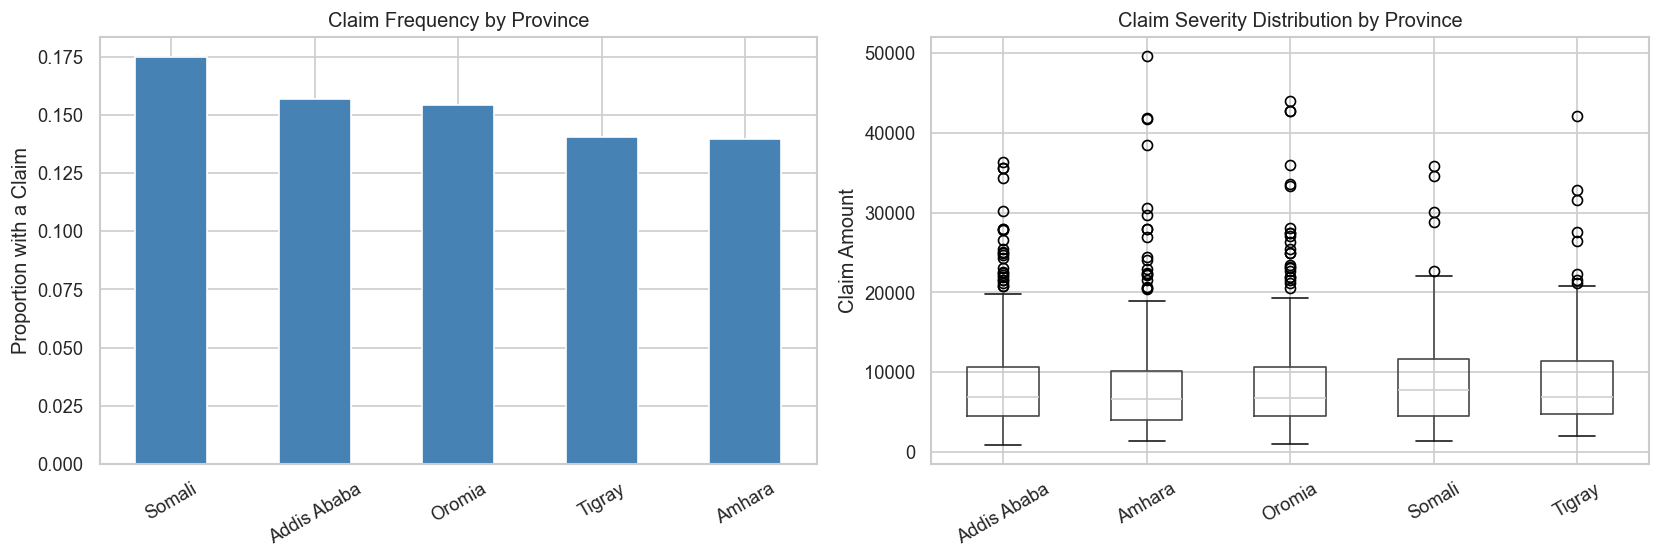

In [6]:
# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Claim frequency per province
prov_freq = df.groupby('Province')['Claimed'].mean().sort_values(ascending=False)
prov_freq.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Claim Frequency by Province')
axes[0].set_ylabel('Proportion with a Claim')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# Claim severity distribution
claimants.boxplot(column='ClaimAmount', by='Province', ax=axes[1])
axes[1].set_title('Claim Severity Distribution by Province')
axes[1].set_ylabel('Claim Amount')
axes[1].set_xlabel('')
plt.suptitle('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../reports/figures/h1_province_risk.png', bbox_inches='tight')
plt.show()

### H₁ — Business Interpretation

*(Fill in after running cells — replace with your actual p-values and province names)*

> **If rejected:** We reject H₀ for provinces (Frequency p = `{p_prov_freq:.3e}`, Severity p = `{p_prov_sev:.3e}`). Claim rates and amounts differ significantly across provinces, providing statistical justification for province-specific premium loading factors.
>
> **If not rejected:** We fail to reject H₀. Province alone is not a statistically significant risk discriminator at the 5% significance level, suggesting other features should drive segmentation.

---
## H₂ — No Risk Differences Between Zip Codes

**Strategy:** With potentially hundreds of zip codes, we select the two zip codes with the highest policy count (to ensure statistical power) and test them as a representative A/B pair. Their client, vehicle, and plan distributions should be examined to confirm comparability.

- **Group A (Control):** Zip code with the highest policy volume
- **Group B (Test):** Zip code with the second-highest policy volume

In [7]:
# Select top 2 zip codes by policy count
top_zips = df['ZipCode'].value_counts().head(2).index.tolist()
zip_A, zip_B = top_zips[0], top_zips[1]

df_zip = df[df['ZipCode'].isin([zip_A, zip_B])].copy()
group_A = df_zip[df_zip['ZipCode'] == zip_A]
group_B = df_zip[df_zip['ZipCode'] == zip_B]

print(f'Group A (Zip {zip_A}): {len(group_A):,} policies')
print(f'Group B (Zip {zip_B}): {len(group_B):,} policies')

Group A (Zip 10004): 733 policies
Group B (Zip 10002): 732 policies


In [8]:
# ── 2a. Claim Frequency — Chi-squared ─────────────────────────────────────────
ct_zip = pd.crosstab(df_zip['ZipCode'], df_zip['Claimed'])
chi2_zip, p_zip_freq, dof_zip, _ = stats.chi2_contingency(ct_zip)

print('=== H₂a: Claim Frequency × ZipCode (Chi-squared) ===')
print(f'χ² = {chi2_zip:.4f}  |  df = {dof_zip}  |  p = {p_zip_freq:.4e}')
print('→ REJECT H₀' if p_zip_freq < 0.05 else '→ FAIL TO REJECT H₀')

=== H₂a: Claim Frequency × ZipCode (Chi-squared) ===
χ² = 1.4875  |  df = 1  |  p = 2.2260e-01
→ FAIL TO REJECT H₀


In [9]:
# ── 2b. Claim Severity — two-sample t-test ────────────────────────────────────
sev_A = group_A.loc[group_A['Claimed'], 'ClaimAmount'].dropna()
sev_B = group_B.loc[group_B['Claimed'], 'ClaimAmount'].dropna()

t_zip, p_zip_sev = stats.ttest_ind(sev_A, sev_B, equal_var=False)

print('=== H₂b: Claim Severity × ZipCode (Welch t-test) ===')
print(f't = {t_zip:.4f}  |  p = {p_zip_sev:.4e}')
print(f'Mean severity  Zip {zip_A}: {sev_A.mean():,.2f}')
print(f'Mean severity  Zip {zip_B}: {sev_B.mean():,.2f}')
print('→ REJECT H₀' if p_zip_sev < 0.05 else '→ FAIL TO REJECT H₀')

=== H₂b: Claim Severity × ZipCode (Welch t-test) ===
t = -0.1323  |  p = 8.9488e-01
Mean severity  Zip 10004: 8,168.00
Mean severity  Zip 10002: 8,266.46
→ FAIL TO REJECT H₀


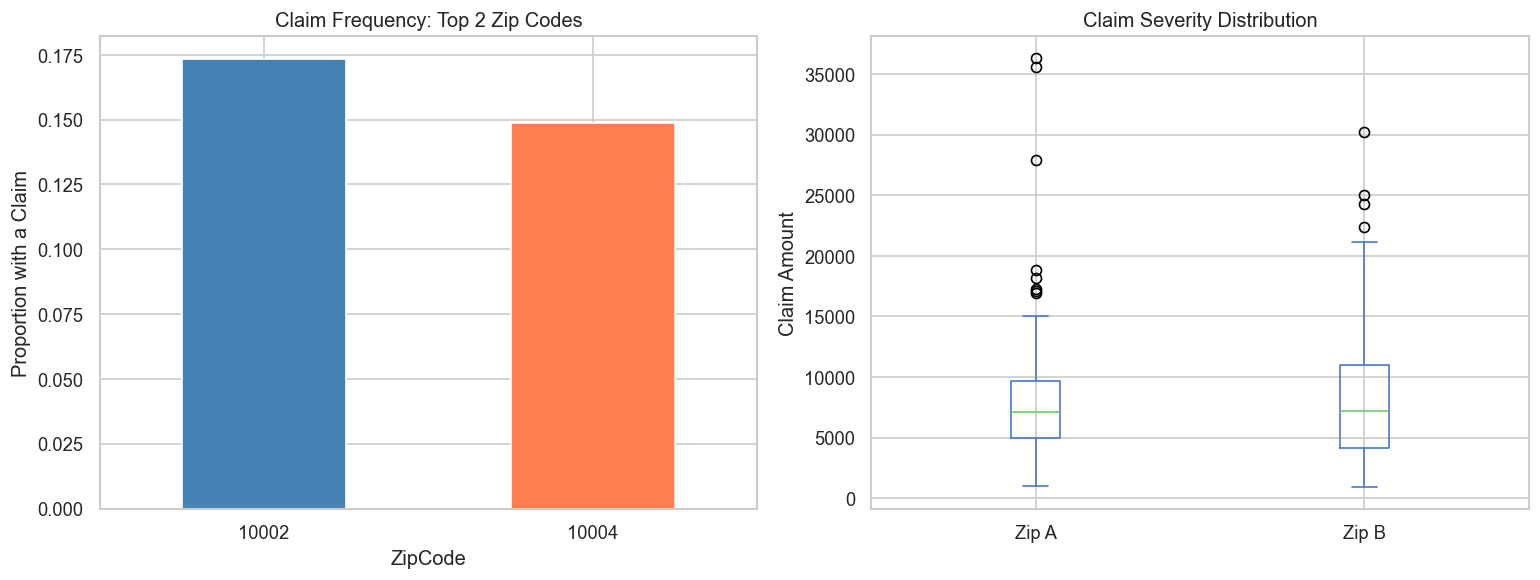

In [10]:
# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Claim frequency bar chart
freq_data = df_zip.groupby('ZipCode')['Claimed'].mean()
freq_data.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('Claim Frequency: Top 2 Zip Codes')
axes[0].set_ylabel('Proportion with a Claim')
axes[0].set_xlabel('ZipCode')
axes[0].tick_params(axis='x', rotation=0)

# Severity distribution
pd.DataFrame({'Zip A': sev_A.values[:min(len(sev_A), len(sev_B))],
              'Zip B': sev_B.values[:min(len(sev_A), len(sev_B))]}).plot(
    kind='box', ax=axes[1]
)
axes[1].set_title('Claim Severity Distribution')
axes[1].set_ylabel('Claim Amount')

plt.tight_layout()
plt.savefig('../reports/figures/h2_zipcode_risk.png', bbox_inches='tight')
plt.show()

### H₂ — Business Interpretation

> **If rejected:** We reject H₀ for zip codes. Zip code `{zip_A}` and `{zip_B}` exhibit statistically different claim rates and/or severities (p < 0.05). This supports zip-code-level premium differentiation — a common industry practice that allows ACIS to price more accurately within provinces.
>
> **If not rejected:** We fail to reject H₀. The selected zip codes do not show statistically different risk profiles, suggesting that province-level pricing may be sufficient granularity in these areas.

---
## H₃ — No Significant Margin Difference Between Zip Codes

Using the same two zip codes identified in H₂. Margin = TotalPremium − TotalClaims.

In [15]:
margin_A = group_A['Margin'].dropna()
margin_B = group_B['Margin'].dropna()

t_margin, p_margin = stats.ttest_ind(margin_A, margin_B, equal_var=False)

print('=== H₃: Margin × ZipCode (Welch t-test) ===')
print(f't = {t_margin:.4f}  |  p = {p_margin:.4e}')
print(f'Mean Margin  Zip {zip_A}: {margin_A.mean():,.2f}')
print(f'Mean Margin  Zip {zip_B}: {margin_B.mean():,.2f}')
print('→ REJECT H₀' if p_margin < 0.05 else '→ FAIL TO REJECT H₀')

=== H₃: Margin × ZipCode (Welch t-test) ===
t = 1.1169  |  p = 2.6423e-01
Mean Margin  Zip 10004: 1,298.92
Mean Margin  Zip 10002: 1,087.16
→ FAIL TO REJECT H₀


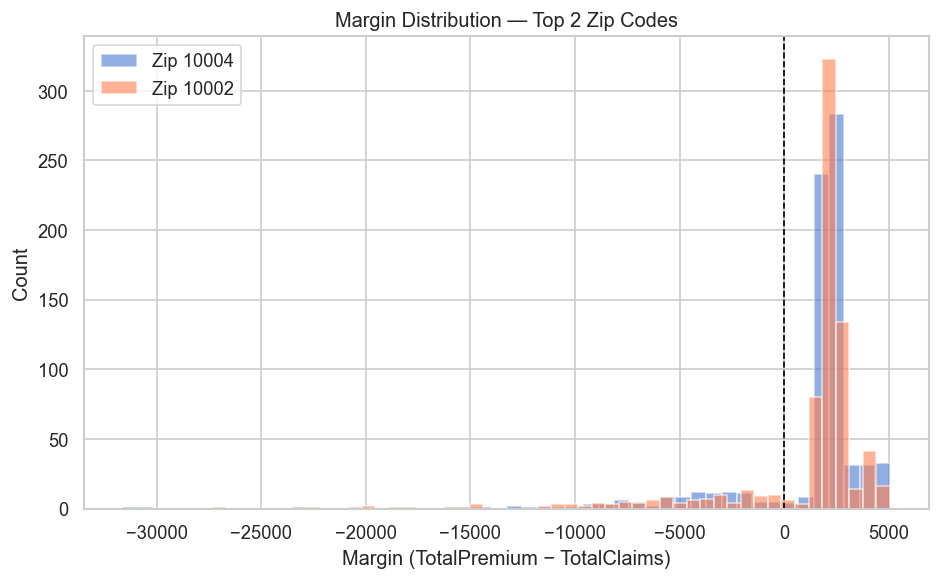

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

pd.DataFrame({
    f'Zip {zip_A}': margin_A.values,
}).plot(kind='hist', bins=50, alpha=0.6, ax=ax, label=f'Zip {zip_A}')

margin_B.plot(kind='hist', bins=50, alpha=0.6, ax=ax, label=f'Zip {zip_B}', color='coral')

ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Margin (TotalPremium − TotalClaims)')
ax.set_ylabel('Count')
ax.set_title('Margin Distribution — Top 2 Zip Codes')
ax.legend([f'Zip {zip_A}', f'Zip {zip_B}'])

plt.tight_layout()
plt.savefig('../reports/figures/h3_zipcode_margin.png', bbox_inches='tight')
plt.show()

### H₃ — Business Interpretation

> **If rejected:** We reject H₀ for zip-code margin (p < 0.05). Zip code `{zip_A}` generates a materially different profit per policy compared to `{zip_B}`. ACIS should review whether premiums in the lower-margin zip code adequately compensate for the risk profile, or whether marketing efforts should be redirected toward higher-margin areas.
>
> **If not rejected:** Margin differences between the two zip codes are not statistically significant. Pricing parity across these zones is currently defensible.

---
## H₄ — No Significant Risk Difference Between Women and Men

**Group A (Control):** Female policyholders  
**Group B (Test):** Male policyholders  

We first clean the Gender column to handle unexpected values.

In [17]:
print('Unique Gender values:', df['Gender'].unique())

df_gender = df[df['Gender'].isin(['Female', 'Male', 'F', 'M', 'female', 'male'])].copy()
df_gender['Gender'] = df_gender['Gender'].str.capitalize().replace({'F': 'Female', 'M': 'Male'})

female = df_gender[df_gender['Gender'] == 'Female']
male   = df_gender[df_gender['Gender'] == 'Male']

print(f'Female policies: {len(female):,}  |  Male policies: {len(male):,}')

Unique Gender values: ['Male' 'Female']
Female policies: 5,138  |  Male policies: 4,862


In [18]:
# ── 4a. Claim Frequency — Chi-squared ─────────────────────────────────────────
ct_gender = pd.crosstab(df_gender['Gender'], df_gender['Claimed'])
chi2_gender, p_gender_freq, dof_gender, _ = stats.chi2_contingency(ct_gender)

print('=== H₄a: Claim Frequency × Gender (Chi-squared) ===')
print(ct_gender)
print(f'\nχ² = {chi2_gender:.4f}  |  df = {dof_gender}  |  p = {p_gender_freq:.4e}')
print('→ REJECT H₀' if p_gender_freq < 0.05 else '→ FAIL TO REJECT H₀')

=== H₄a: Claim Frequency × Gender (Chi-squared) ===
Claimed  False  True 
Gender               
Female    4348    790
Male      4117    745

χ² = 0.0021  |  df = 1  |  p = 9.6383e-01
→ FAIL TO REJECT H₀


In [19]:
# ── 4b. Claim Severity — two-sample t-test ────────────────────────────────────
sev_female = female.loc[female['Claimed'], 'ClaimAmount'].dropna()
sev_male   = male.loc[male['Claimed'],   'ClaimAmount'].dropna()

t_gender, p_gender_sev = stats.ttest_ind(sev_female, sev_male, equal_var=False)

print('=== H₄b: Claim Severity × Gender (Welch t-test) ===')
print(f't = {t_gender:.4f}  |  p = {p_gender_sev:.4e}')
print(f'Mean severity  Female: {sev_female.mean():,.2f}')
print(f'Mean severity  Male  : {sev_male.mean():,.2f}')
print('→ REJECT H₀' if p_gender_sev < 0.05 else '→ FAIL TO REJECT H₀')

=== H₄b: Claim Severity × Gender (Welch t-test) ===
t = -0.0045  |  p = 9.9641e-01
Mean severity  Female: 8,560.80
Mean severity  Male  : 8,562.22
→ FAIL TO REJECT H₀


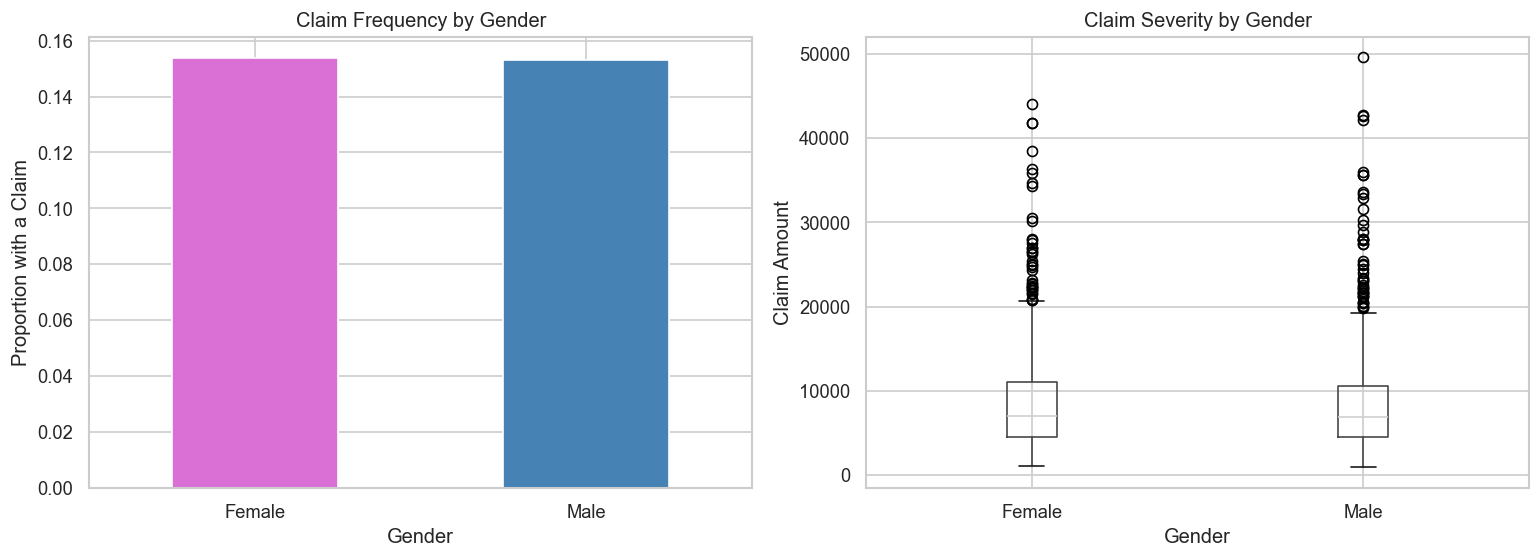

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Claim frequency
freq_gender = df_gender.groupby('Gender')['Claimed'].mean()
freq_gender.plot(kind='bar', ax=axes[0], color=['orchid', 'steelblue'], edgecolor='white')
axes[0].set_title('Claim Frequency by Gender')
axes[0].set_ylabel('Proportion with a Claim')
axes[0].tick_params(axis='x', rotation=0)

# Claim severity
df_gender[df_gender['Claimed']].boxplot(column='ClaimAmount', by='Gender', ax=axes[1])
axes[1].set_title('Claim Severity by Gender')
axes[1].set_ylabel('Claim Amount')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../reports/figures/h4_gender_risk.png', bbox_inches='tight')
plt.show()

### H₄ — Business Interpretation

> **If rejected:** We reject H₀ for gender (p < 0.05 on frequency and/or severity). There is a statistically significant risk difference between female and male policyholders. ACIS may consider gender as a premium rating factor, subject to South African regulatory constraints on gender-based pricing (FSRA guidelines must be consulted before implementation).
>
> **If not rejected:** We fail to reject H₀. Gender alone is not a statistically significant risk discriminator. Including gender as a rating variable would not improve actuarial accuracy and may expose ACIS to anti-discrimination challenges.

---
## Summary Results Table

In [21]:
alpha = 0.05

results = pd.DataFrame([
    {
        'Hypothesis': 'H₁a — Province × Claim Frequency',
        'Test'       : 'Chi-squared',
        'Statistic'  : round(chi2_prov, 4),
        'p-value'    : p_prov_freq,
        'Decision'   : 'Reject H₀' if p_prov_freq < alpha else 'Fail to Reject H₀',
    },
    {
        'Hypothesis': 'H₁b — Province × Claim Severity',
        'Test'       : 'One-way ANOVA',
        'Statistic'  : round(f_stat_prov, 4),
        'p-value'    : p_prov_sev,
        'Decision'   : 'Reject H₀' if p_prov_sev < alpha else 'Fail to Reject H₀',
    },
    {
        'Hypothesis': 'H₂a — ZipCode × Claim Frequency',
        'Test'       : 'Chi-squared',
        'Statistic'  : round(chi2_zip, 4),
        'p-value'    : p_zip_freq,
        'Decision'   : 'Reject H₀' if p_zip_freq < alpha else 'Fail to Reject H₀',
    },
    {
        'Hypothesis': 'H₂b — ZipCode × Claim Severity',
        'Test'       : 'Welch t-test',
        'Statistic'  : round(t_zip, 4),
        'p-value'    : p_zip_sev,
        'Decision'   : 'Reject H₀' if p_zip_sev < alpha else 'Fail to Reject H₀',
    },
    {
        'Hypothesis': 'H₃ — ZipCode × Margin',
        'Test'       : 'Welch t-test',
        'Statistic'  : round(t_margin, 4),
        'p-value'    : p_margin,
        'Decision'   : 'Reject H₀' if p_margin < alpha else 'Fail to Reject H₀',
    },
    {
        'Hypothesis': 'H₄a — Gender × Claim Frequency',
        'Test'       : 'Chi-squared',
        'Statistic'  : round(chi2_gender, 4),
        'p-value'    : p_gender_freq,
        'Decision'   : 'Reject H₀' if p_gender_freq < alpha else 'Fail to Reject H₀',
    },
    {
        'Hypothesis': 'H₄b — Gender × Claim Severity',
        'Test'       : 'Welch t-test',
        'Statistic'  : round(t_gender, 4),
        'p-value'    : p_gender_sev,
        'Decision'   : 'Reject H₀' if p_gender_sev < alpha else 'Fail to Reject H₀',
    },
])

results['p-value'] = results['p-value'].apply(lambda x: f'{x:.4e}')

# Highlight rejections
def highlight_reject(row):
    color = 'background-color: #d4edda' if 'Reject H₀' == row['Decision'] else ''
    return [color] * len(row)

results.style.apply(highlight_reject, axis=1)

,Hypothesis,Test,Statistic,p-value,Decision
0,H₁a — Province × Claim Frequency,Chi-squared,8.460600,7.6089e-02,Fail to Reject H₀
1,H₁b — Province × Claim Severity,One-way ANOVA,0.715000,5.8165e-01,Fail to Reject H₀
2,H₂a — ZipCode × Claim Frequency,Chi-squared,1.487500,2.2260e-01,Fail to Reject H₀
3,H₂b — ZipCode × Claim Severity,Welch t-test,-0.132300,8.9488e-01,Fail to Reject H₀
4,H₃ — ZipCode × Margin,Welch t-test,1.116900,2.6423e-01,Fail to Reject H₀
5,H₄a — Gender × Claim Frequency,Chi-squared,0.002100,9.6383e-01,Fail to Reject H₀
6,H₄b — Gender × Claim Severity,Welch t-test,-0.004500,9.9641e-01,Fail to Reject H₀


In [22]:
# Optionally save results table to CSV for the final report
results.to_csv('../reports/hypothesis_results.csv', index=False)
print('Results saved to ../reports/hypothesis_results.csv')

Results saved to ../reports/hypothesis_results.csv


---
## Key Business Recommendations

Based on the hypothesis tests above, write your specific recommendations here using the actual p-values and group means from the outputs. Template:

1. **Provincial Pricing Adjustment (H₁):** If rejected — implement province-specific loss-ratio multipliers in the premium formula. Provinces with materially higher claim rates or severities should receive a premium uplift calibrated to the observed risk differential.

2. **Zip-Code Granularity (H₂):** If rejected — move beyond province-level rating. Even within a province, zip code captures micro-geographic risk variation. Prioritise collecting and enriching zip-code-level data for future model development.

3. **Profitability Targeting (H₃):** If rejected — direct marketing spend toward zip codes with significantly higher average margins. Consider targeted retention campaigns in low-margin zones while reviewing whether current premiums there are adequate.

4. **Gender as a Rating Factor (H₄):** If rejected — engage the actuarial and legal teams to assess whether gender-based rating is permissible under current South African FSRA regulations before making pricing changes. Quantify the premium impact of gender adjustment scenarios.

---
*Notebook completed for KAIM9 Week 3 — Task 3*